In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Mineral ores round the world.csv to Mineral ores round the world.csv


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("Mineral ores round the world.csv", low_memory=False)

In [ ]:
df.head(5)

,site_name,latitude,longitude,region,country,state,county,com_type,commod1,commod2,...,dep_type,prod_size,dev_stat,ore,gangue,work_type,names,ore_ctrl,hrock_type,arock_type
0,Lookout Prospect,55.05612,-132.14344,NaN,United States,Alaska,NaN,M,Copper,"Gold, Silver",...,NaN,N,Occurrence,"Chalcopyrite, Covellite, Pyrite","Quartz, Sericite",NaN,"Conundrum, Mammoth, Wakefield Minerals Co.",NaN,Schist,NaN
1,Lucky Find Prospect,55.52751,-132.68514,NaN,United States,Alaska,NaN,M,Copper,Gold,...,NaN,N,Occurrence,"Chalcopyrite, Pyrite","Calcite, Quartz, Siderite",Underground,NaN,Vein Follows Contact,Diabase,NaN
2,Mccullough Prospect,55.97751,-132.99906,NaN,United States,Alaska,NaN,M,Copper,NaN,...,NaN,N,Occurrence,"Chalcopyrite, Pyrite, Sphalerite",Quartz,NaN,"Claims: Horseshoe, Copper, Lake Bay",NaN,Siltstone,NaN
3,Lucky Jim Claim,55.52195,-132.68653,NaN,United States,Alaska,NaN,M,Gold,NaN,...,NaN,N,Occurrence,"Galena, Malachite, Pyrite",NaN,NaN,NaN,NaN,Granite,Granite
4,Matilda Occurrence,55.14556,-132.05233,NaN,United States,Alaska,NaN,M,Gold,NaN,...,NaN,N,Occurrence,Pyrite,NaN,NaN,NaN,NaN,Mica Schist,NaN


In [ ]:
df["gangue"].isnull().sum()



np.int64(271624)

In [ ]:
df["ore"].isnull().sum()

np.int64(234074)

In [ ]:
df["commod1"].isnull().sum()

np.int64(21031)

In [ ]:
df["ore_ctrl"].value_counts()

,count
ore_ctrl,
Shear Zone,676
Fault,537
Fractures,371
Fault Zone,319
Fault-Fracture Structural Control.,267
...,...
Along A N70w Fracture,1
Ore Occurs In Small Bedded Replacements In Limestone,1
Favorable Horizons,1


In [ ]:
a=["latitude", "longitude", "commod1"]
df_new=df[a]

In [ ]:
df_new.value_counts()

latitude   longitude   commod1        
-42.66279   146.33176  Osmium, Iridium    112
 39.74249  -105.51369  Gold               103
 38.97399  -109.56795  Uranium             53
 42.36105  -123.55343  Chromium            44
 38.99027  -110.69985  Uranium             35
                                         ... 
 36.97118  -90.48180   Iron                 1
 36.97117  -93.73211   Lead, Zinc           1
           -94.08352   Lead                 1
           -94.50273   Zinc, Lead           1
 36.97178  -90.56231   Iron                 1
Name: count, Length: 273912, dtype: int64

In [ ]:
df_new=df_new.dropna(subset=["latitude","longitude"])

In [ ]:
df_new["latitude"].isna().sum()

np.int64(0)

In [ ]:
df_new["commod1"].value_counts().head(7)

,count
commod1,
Gold,56896
"Sand and Gravel, Construction",45463
"Stone, Crushed/Broken",16454
Copper,14893
Iron,13533
Uranium,9044
Silver,6437


In [ ]:
metals=["Gold","Copper","Iron"]
df_final=df_new[df_new["commod1"].isin(metals)].copy()



In [ ]:
df_final["commod1"].value_counts()

,count
commod1,
Gold,56896
Copper,14893
Iron,13533


In [ ]:
df_final.head()

,latitude,longitude,commod1
0,55.05612,-132.14344,Copper
1,55.52751,-132.68514,Copper
2,55.97751,-132.99906,Copper
3,55.52195,-132.68653,Gold
4,55.14556,-132.05233,Gold


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df_final["metals"]=encoder.fit_transform(df_final["commod1"])


In [ ]:
df_final

,latitude,longitude,commod1,metals
0,55.05612,-132.14344,Copper,0
1,55.52751,-132.68514,Copper,0
2,55.97751,-132.99906,Copper,0
3,55.52195,-132.68653,Gold,1
4,55.14556,-132.05233,Gold,1
...,...,...,...,...
304616,41.20830,-106.26110,Gold,1
304626,-20.49747,-43.87395,Iron,2
304629,14.44527,-87.29280,Iron,2
304630,12.21347,-85.16665,Gold,1


In [ ]:
mapping=dict(zip(encoder.classes_,encoder.transform(encoder.classes_)))


In [ ]:
print(f"The Metal Mapping: {mapping}")

The Metal Mapping: {'Copper': np.int64(0), 'Gold': np.int64(1), 'Iron': np.int64(2)}


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X=df_final.drop((["commod1","metals"]), axis=1)

In [ ]:
X

,latitude,longitude
0,55.05612,-132.14344
1,55.52751,-132.68514
2,55.97751,-132.99906
3,55.52195,-132.68653
4,55.14556,-132.05233
...,...,...
304616,41.20830,-106.26110
304626,-20.49747,-43.87395
304629,14.44527,-87.29280
304630,12.21347,-85.16665


In [ ]:
y=df_final["metals"]

In [ ]:
X

,latitude,longitude
0,55.05612,-132.14344
1,55.52751,-132.68514
2,55.97751,-132.99906
3,55.52195,-132.68653
4,55.14556,-132.05233
...,...,...
304616,41.20830,-106.26110
304626,-20.49747,-43.87395
304629,14.44527,-87.29280
304630,12.21347,-85.16665


In [ ]:
y

,metals
0,0
1,0
2,0
3,1
4,1
...,...
304616,1
304626,2
304629,2
304630,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
forestmodel=RandomForestClassifier(class_weight='balanced')

In [ ]:
forestmodel.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced')

In [ ]:
y_pred=forestmodel.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)


In [ ]:
accuracy

0.9012012891883973

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [ ]:
cm=confusion_matrix(y_test, y_pred)
cm

array([[ 2120,   721,   104],
       [  435, 10876,    90],
       [  152,   184,  2383]])

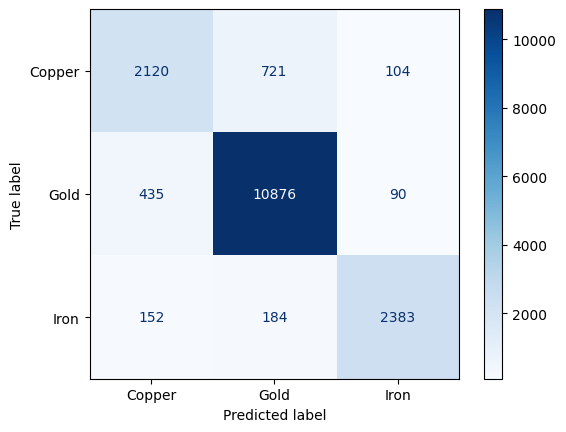

In [ ]:
cmd=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=encoder.classes_)

cmd.plot(cmap='Blues')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
creport=classification_report(y_test, y_pred, target_names= encoder.classes_)

In [ ]:
print(creport)


              precision    recall  f1-score   support

      Copper       0.78      0.72      0.75      2945
        Gold       0.92      0.95      0.94     11401
        Iron       0.92      0.88      0.90      2719

    accuracy                           0.90     17065
   macro avg       0.88      0.85      0.86     17065
weighted avg       0.90      0.90      0.90     17065



In [ ]:
print(f"Latitude range: {df_final['latitude'].min()} to {df_final['latitude'].max()}")
print(f"Longitude range: {df_final['longitude'].min()} to {df_final['longitude'].max()}")

Latitude range: -72.99718 to 80.00096
Longitude range: -178.80231 to 179.1318


In [ ]:
nevada_spot=[[40.9,-116.3]]
new_result=forestmodel.predict(nevada_spot)
name=(encoder.inverse_transform(new_result))
print(name)


['Gold']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print(f"For the Nevada coordinate, the AI predicts: {name[0]}")

For the Nevada coordinate, the AI predicts: Gold


In [ ]:
brazil_mine=[[-6.06,-50.18]]
new_result=forestmodel.predict(brazil_mine)
name=(encoder.inverse_transform(new_result))
print(name[0])

Gold


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
importances=forestmodel.feature_importances_

In [ ]:
importances

array([0.4092507, 0.5907493])

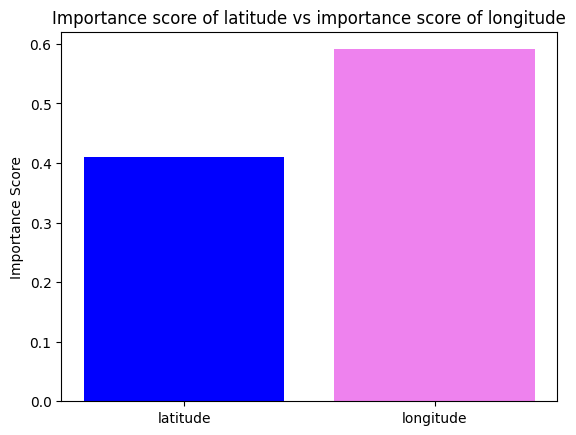

In [ ]:
features=['latitude','longitude']

plt.bar(features, importances, color=["blue","violet"])
plt.title("Importance score of latitude vs importance score of longitude")
plt.ylabel("Importance Score")
plt.show()

In [ ]:
print(f"Latitude Importance: {importances[0]:.4f}")
print(f"Longitude Importance: {importances[1]:.4f}")

Latitude Importance: 0.4093
Longitude Importance: 0.5907


In [ ]:
lat_min, lat_max= 35,45 #general latitudes of the state of nevada
long_min, long_max= -120,-110 #general longitudes of the state of nevada

lat_grid = np.linspace(lat_min, lat_max,100)
long_grid= np.linspace(long_min, long_max,100)
LAT, LONG = np.meshgrid(lat_grid, long_grid)

In [ ]:
LAT.shape


(100, 100)

In [ ]:
lat_grid.shape

(100,)

In [ ]:
grid_points = np.c_[LAT.ravel(), LONG.ravel()]

In [ ]:
grid_points.shape

(10000, 2)

In [ ]:
grid_preds=forestmodel.predict_proba(grid_points)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
gold_idx = encoder.transform(['Gold'])[0]
Z = grid_preds.reshape(LAT.shape)

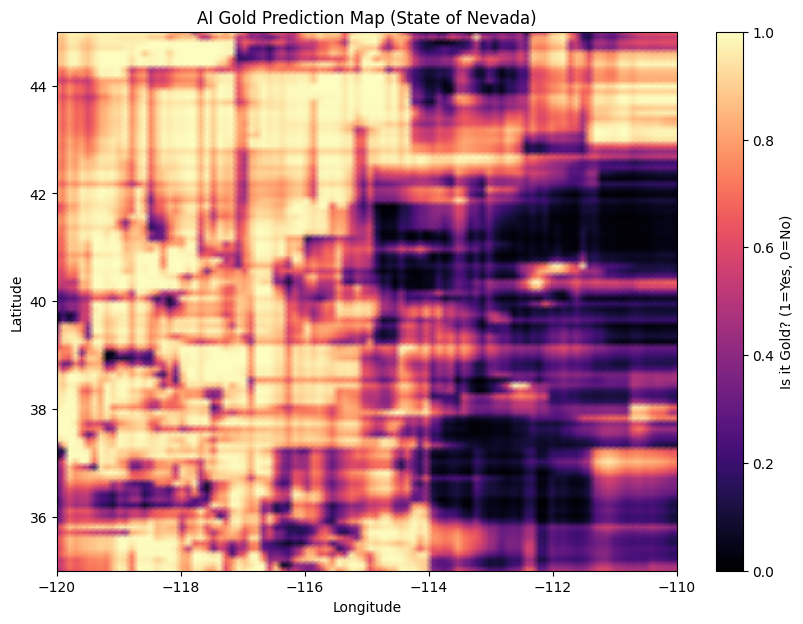

In [ ]:
plt.figure(figsize=(10,7))
plt.pcolormesh(LONG,LAT,Z,cmap='magma', shading='gouraud')
plt.colorbar(label='Is it Gold? (1=Yes, 0=No)')
plt.title('AI Gold Prediction Map (State of Nevada)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [ ]:
import joblib
joblib.dump(forestmodel, 'foundation_ore_predictor.pkl')

['foundation_ore_predictor.pkl']